# Discrete Contact

In [2]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

import numpy as np
import matplotlib.pyplot as plt

from syssimx_examples.controlled_pendulum.components import FMUPendulum
from syssimx_examples.controlled_pendulum import MasterPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection

PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Configuration of the Master Pendulum

In [3]:
mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

fem_parameters = {'mat_params': mat_params}

master_pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
master_pendulum.set_parameters(**{"FEM": fem_parameters})

master_pendulum.initialize(t0=0.0)

pendulum_mass = master_pendulum.fem.mass
pendulum_length = master_pendulum.fem._equivalent_length
pendulum_inertia = master_pendulum.fem.inertia

print(f"Pendulum Mass: {pendulum_mass:.4f} kg")
print(f"Pendulum Length: {pendulum_length:.4f} m")
print(f"Pendulum Inertia: {pendulum_inertia:.6f} kg*m^2")
pendulum = master_pendulum.models["FMU"]

Pendulum Mass: 1.0843 kg
Pendulum Length: 0.1817 m
Pendulum Inertia: 0.044227 kg*m^2


In [9]:
# from OMPython import ModelicaSystem

# ref_system = ModelicaSystem(fileName=str(package_path / "package.mo"),
#                            modelName="ControlledPendulum.Examples.Contact.RigidContact")

# ref_system.setParameters({"pendulum.m": pendulum_mass})
# ref_system.setParameters({"pendulum.L": pendulum_length})
# ref_system.setParameters({"pendulum.J": pendulum_inertia})
# ref_system.setParameters({"useReset": True})

# ref_system.buildModel()

# ref_system.simulate()

# solution_names = ('time',
#                   'theta_ref',
#                   'theta_meas',
#                   'theta',
#                   'pendulum.contact',
#                   'u_control',
#                   'pid.I_out')
# ref_solutions = {name: ref_system.getSolutions(name).flatten() for name in solution_names}

## Co-Simulation with FMU Pendulum

In [10]:
set_point = FMUComponent(name="SetPoint", fmu_path=fmu_paths['Trajectories']["SetPoint"], group="Controller")
drive = FMUComponent(name="Drive", fmu_path=fmu_paths['Actuators']["DriveDynamic"], group="Actuator")

angle_sensor = FMUComponent(name="Angle Sensor", fmu_path=fmu_paths['Sensors']['AngleSensor'], group="Sensor")
angle_decoder = FMUComponent(name="Decoder", fmu_path=fmu_paths['Sensors']['AngleDecoder'], group="Controller")

nBits = 12
angle_sensor.set_parameters(nBits=nBits)
angle_decoder.set_parameters(nBits=nBits)

class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDControllerReset_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")
    
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

pendulum = FMUPendulum(name="FMUPendulum",
                       solver="cvode")
pendulum.set_parameters(**{
    'J': pendulum_inertia,
    'm': pendulum_mass,
    'L': pendulum_length,
})

def wall_contact_indicator(comp: MasterPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0
    return theta - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

In [11]:
c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [set_point, pid, drive, pendulum, angle_decoder, angle_sensor]

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

event_connections = [event_connection_1, event_connection_2]

from syssimx import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

for event_conn in event_connections:
    system.add_event_connection(event_conn)

system.initialize(t0=0.0)

In [14]:
system.algorithm.record_internal_steps = False

In [19]:
t = 0.0
t_end = 2.0
dt = 0.001
system.run(t, t_end, dt)

: 

In [17]:
history = system.get_history()

t_decoder = history[angle_decoder.name][0]
t_sensor = history[angle_sensor.name][0]
t_pendulum = history[pendulum.name][0]
t_pid = history[pid.name][0]

theta_meas = history[angle_decoder.name][1]["theta"]
theta = history[pendulum.name][1]["theta"]
v_out = history[angle_sensor.name][1]["v_out"]
u_control = history[pid.name][1]["u"]

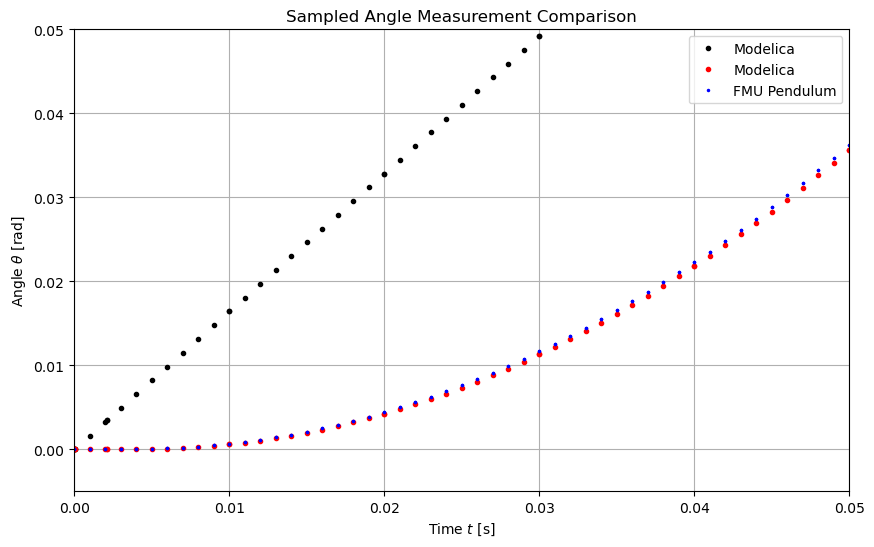

In [18]:
plt.figure(figsize=(10, 6))
plt.title("Sampled Angle Measurement Comparison")
plt.plot(ref_solutions['time'], ref_solutions['theta_ref'], label="Modelica", color="black", linestyle='None', marker='.')
plt.plot(ref_solutions['time'], ref_solutions['theta'], label="Modelica", color="red", linestyle='None', marker='.')
plt.plot(t_pendulum, theta, label="FMU Pendulum", color="blue", linestyle='None', marker='.', markersize=3)
plt.xlim(0, 0.05)
plt.ylim(-0.005, 0.05)
plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Angle $\theta$ [rad]")
plt.legend()
plt.grid()
plt.show()

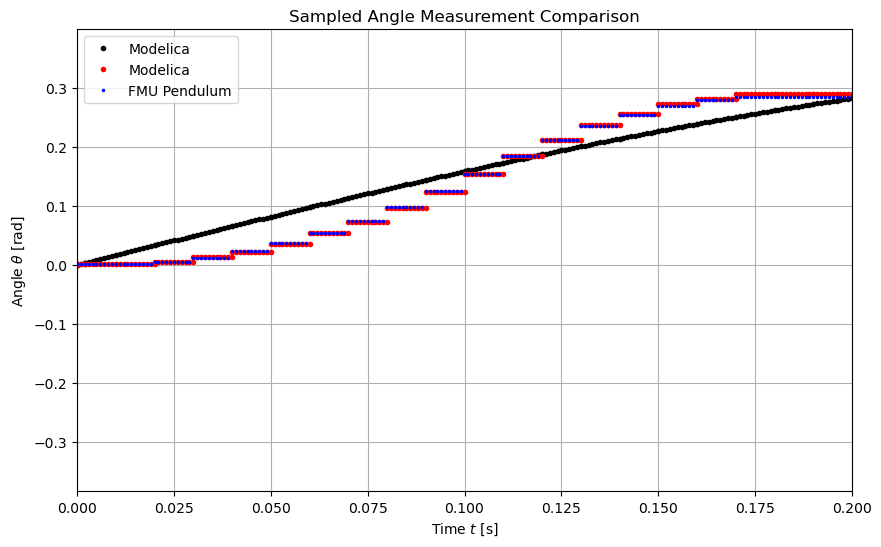

In [19]:
t_decoder = history['Decoder'][0]
theta_meas = history['Decoder'][1]['theta']

plt.figure(figsize=(10, 6))
plt.title("Sampled Angle Measurement Comparison")
plt.plot(ref_solutions['time'], ref_solutions['theta_ref'], label="Modelica", color="black", linestyle='None', marker='.')
plt.plot(ref_solutions['time'], ref_solutions['theta_meas'], label="Modelica", color="red", linestyle='None', marker='.')
plt.plot(t_decoder, theta_meas, label="FMU Pendulum", color="blue", linestyle='None', marker='.', markersize=3)
plt.xlim(0, 0.2)
#plt.ylim(-0.005, 0.35)
plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Angle $\theta$ [rad]")
plt.legend()
plt.grid()
plt.show()

**PID**

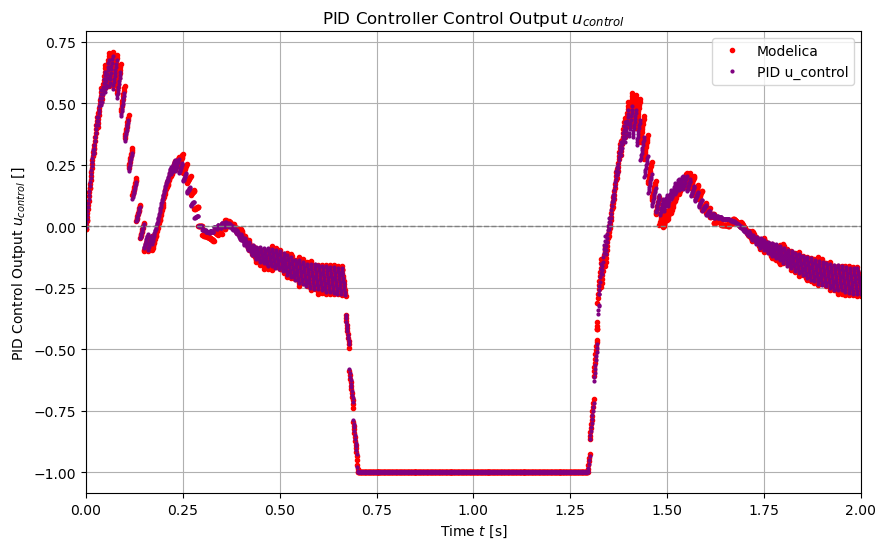

In [28]:
pid_hist = history['PID']
t_pid, data_pid = pid_hist
u_control = data_pid['u']

plt.figure(figsize=(10, 6))
plt.title("PID Controller Control Output $u_{control}$")
plt.plot(ref_solutions['time'], ref_solutions['u_control'], label="Modelica", color="red", linestyle='None', marker='.')
plt.plot(t_pid, u_control, '.', label="PID u_control", color="purple", markersize=4)
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlim(0, 2)
plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"PID Control Output $u_{control}$ []")
plt.legend()
plt.grid()
plt.show()

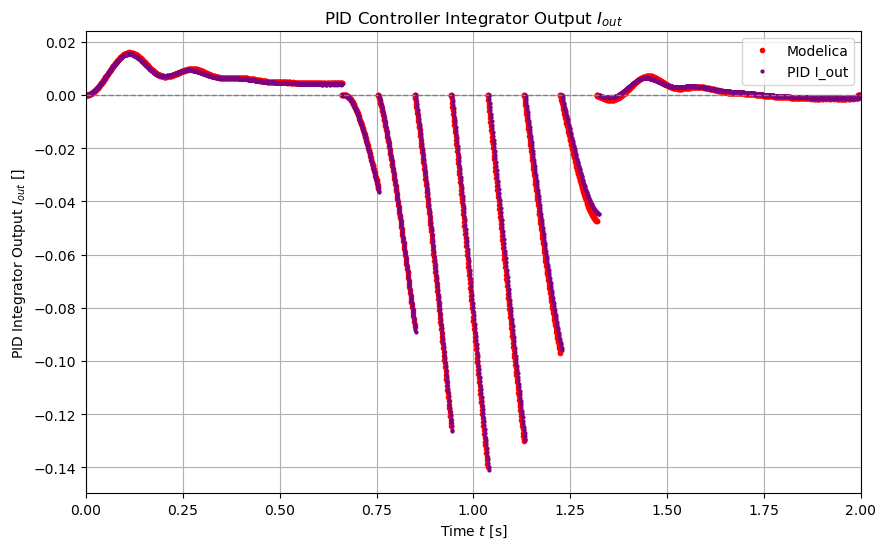

In [29]:
pid_hist = history['PID']
t_pid, data_pid = pid_hist
I_out = data_pid['I_out'] 

plt.figure(figsize=(10, 6))
plt.title("PID Controller Integrator Output $I_{out}$")
plt.plot(ref_solutions['time'], ref_solutions['pid.I_out'], label="Modelica", color="red", linestyle='None', marker='.')
plt.plot(t_pid, I_out, '.', label="PID I_out", color="purple", markersize=4)
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlim(0, 2)
plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"PID Integrator Output $I_{out}$ []")
plt.legend()
plt.grid()
plt.show()